In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import time

In [2]:
print("Fetching MNIST dataset")
mnist = fetch_openml('mnist_784', version=1, cache=True, parser='auto')

X = mnist.data.values.astype('float32') / 255.0
y = mnist.target.values.astype('int')

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=60000, test_size=10000, random_state=42)
print(f"{X_train.shape[0]} train samples, {X_test.shape[0]} test samples.\n")

Fetching MNIST dataset
60000 train samples, 10000 test samples.



In [3]:
d = 2
T_exp = 2  
epochs = int(T_exp)

M_x_list = [] # Stores mistake features for each class
M_y_list = [] # Stores mistake labels for each class
C_vecs = []   # Stores survival times

print(f"Starting Kernel Training (d={d}, T={T_exp})")
start_train_time = time.time()

for c in range(10):
    c_start_time = time.time()
    y_bin = np.where(y_train == c, 1, -1)
    
    mistakes = []
    C = [0]
    
    for epoch in range(epochs):
        for i in range(len(X_train)):
            x_i = X_train[i]
            y_i = y_bin[i]
            
            if len(mistakes) == 0:
                v_dot_x = 0.0
            else:
                # Vectorized kernel calculation against all historical mistakes
                M_x_arr = np.array([m[0] for m in mistakes])
                M_y_arr = np.array([m[1] for m in mistakes])
                v_dot_x = np.sum(M_y_arr * ((np.dot(M_x_arr, x_i) + 1.0) ** d))
                
            y_hat = 1 if v_dot_x >= 0 else -1
            
            if y_hat == y_i:
                C[-1] += 1
            else:
                mistakes.append((x_i, y_i))
                C.append(1)
                
    # Save the history matrices for this class
    if len(mistakes) > 0:
        M_x_list.append(np.array([m[0] for m in mistakes]))
        M_y_list.append(np.array([m[1] for m in mistakes]))
    else:
        M_x_list.append(np.empty((0, X_train.shape[1])))
        M_y_list.append(np.empty(0))
        
    C_vecs.append(np.array(C))
    print(f"  Class {c} completed in {time.time() - c_start_time:.1f}s | Total mistakes: {len(mistakes)}")

print(f"Total time: {time.time() - start_train_time:.1f}s\n")

Starting Kernel Training (d=2, T=2)
  Class 0 completed in 97.2s | Total mistakes: 813
  Class 1 completed in 82.4s | Total mistakes: 684
  Class 2 completed in 167.3s | Total mistakes: 1489
  Class 3 completed in 204.6s | Total mistakes: 1924
  Class 4 completed in 154.0s | Total mistakes: 1378
  Class 5 completed in 165.5s | Total mistakes: 1606
  Class 6 completed in 101.1s | Total mistakes: 978
  Class 7 completed in 136.9s | Total mistakes: 1378
  Class 8 completed in 207.6s | Total mistakes: 2329
  Class 9 completed in 236.1s | Total mistakes: 2444
Training Complete! Total time: 1552.6s



In [4]:
print("Evaluating")
start_eval_time = time.time()

batch_size = 1000
y_pred_all = np.zeros(len(X_test))
conf_method_1 = np.zeros(len(X_test))
conf_method_2 = np.zeros(len(X_test))
conf_method_3 = np.zeros(len(X_test)) 

for i in range(0, len(X_test), batch_size):
    X_batch = X_test[i:i+batch_size]
    batch_scores = np.zeros((len(X_batch), 10))
    batch_signs_list = []
    
    for c in range(10):
        if len(M_x_list[c]) > 0:
            K_matrix = (np.dot(X_batch, M_x_list[c].T) + 1.0) ** d
            K_weighted = K_matrix * M_y_list[c]
            
            H_vals = np.hstack([np.zeros((len(X_batch), 1)), np.cumsum(K_weighted, axis=1)])
            signs = np.where(H_vals >= 0, 1, -1)
            
            batch_signs_list.append(signs)
            batch_scores[:, c] = np.dot(signs, C_vecs[c])
        else:
            batch_signs_list.append(np.ones((len(X_batch), 1)))
            batch_scores[:, c] = np.ones(len(X_batch)) * C_vecs[c][0]
            
    y_pred_batch = np.argmax(batch_scores, axis=1)
    y_pred_all[i:i+batch_size] = y_pred_batch
    
    for j in range(len(X_batch)):
        winner = y_pred_batch[j]
        global_j = i + j
        
        score_winner = batch_scores[j, winner]
        sum_c_winner = np.sum(C_vecs[winner])
        
        # --- Method 1: Normalized Vote ---
        conf_method_1[global_j] = abs(score_winner) / sum_c_winner
        
        # --- Method 2: Unbroken Streak ---
        signs_winner = batch_signs_list[winner][j]
        last_vote = signs_winner[-1]
        reversed_signs = signs_winner[::-1]
        matches = (reversed_signs == last_vote)
        streak = len(signs_winner) if np.all(matches) else np.argmin(matches)
        conf_method_2[global_j] = streak
            
        # --- Method 3: Raw Vote Difference |(+1) - (-1)| ---
        conf_method_3[global_j] = abs(score_winner)

    print(f"  Processed batch {i} to {i+len(X_batch)}...")

print(f"Evaluation Complete! Total time: {time.time() - start_eval_time:.1f}s\n")

Evaluating test set with 3 Confidence Methods...
  Processed batch 0 to 1000...
  Processed batch 1000 to 2000...
  Processed batch 2000 to 3000...
  Processed batch 3000 to 4000...
  Processed batch 4000 to 5000...
  Processed batch 5000 to 6000...
  Processed batch 6000 to 7000...
  Processed batch 7000 to 8000...
  Processed batch 8000 to 9000...
  Processed batch 9000 to 10000...
Evaluation Complete! Total time: 3.3s



Generating Plots...


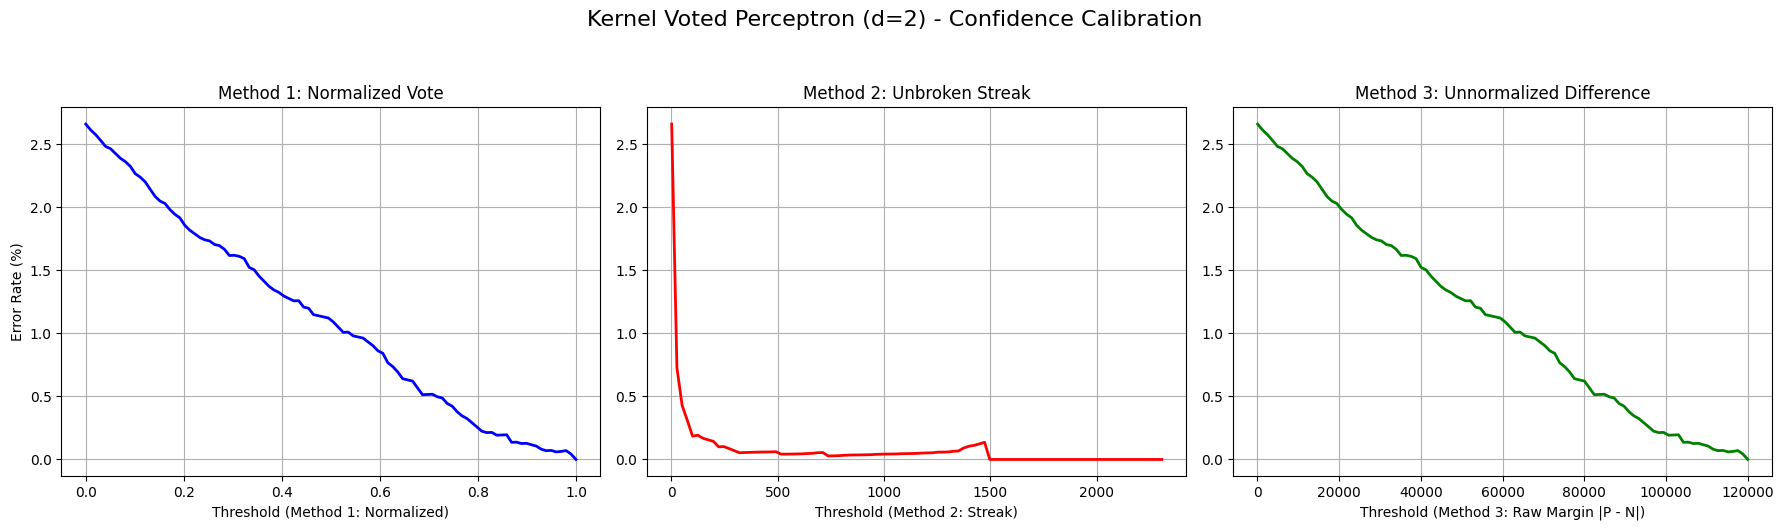

In [5]:
print("Generating Plots...")
mistakes_mask = (y_pred_all != y_test)

def get_error_rates(confidences, mistakes):
    thresholds = np.linspace(np.min(confidences), np.max(confidences), 100)
    error_rates = []
    
    for t in thresholds:
        keep_mask = confidences >= t
        retained = np.sum(keep_mask)
        
        # Enforce minimum 20 samples to prevent crazy random spikes at the end
        if retained > 20: 
            error_rate = np.mean(mistakes[keep_mask]) * 100
            error_rates.append(error_rate)
        else:
            error_rates.append(np.nan)
            
    return thresholds, error_rates

t1, err1 = get_error_rates(conf_method_1, mistakes_mask)
t2, err2 = get_error_rates(conf_method_2, mistakes_mask)
t3, err3 = get_error_rates(conf_method_3, mistakes_mask)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot Method 1
ax1.plot(t1, err1, 'b-', linewidth=2)
ax1.set_xlabel('Threshold (Method 1: Normalized)')
ax1.set_ylabel('Error Rate (%)')
ax1.set_title('Method 1: Normalized Vote')
ax1.grid(True)

# Plot Method 2
ax2.plot(t2, err2, 'r-', linewidth=2)
ax2.set_xlabel('Threshold (Method 2: Streak)')
ax2.set_title('Method 2: Unbroken Streak')
ax2.grid(True)

# Plot Method 3
ax3.plot(t3, err3, 'g-', linewidth=2)
ax3.set_xlabel('Threshold (Method 3: Raw Margin |P - N|)')
ax3.set_title('Method 3: Unnormalized Difference')
ax3.grid(True)

plt.suptitle(f"Kernel Voted Perceptron (d={d}) - Confidence Calibration", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()